# 02 — Balanced causal path

Самостоятельный matched-эксперимент для четырех target-aware outcomes. Проверяет signed amplitude, nonlinear residual и концентрацию causal support на входе Detect head.

In [1]:
from pathlib import Path
import sqlite3, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import wilcoxon
from IPython.display import display

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'new_experiments').exists()), None)
if REPO_ROOT is None: raise RuntimeError('Run from inside PatchSuccessResearch')
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))

from CandidateRoutingAndAttackPath import load_experiment
from CandidateRoutingAndAttackPath.attack_path import AttackPathConfig, load_attack_path_tables, run_attack_path_decomposition
from CandidateRoutingAndAttackPath.balanced_target_path import (
    GROUP_ORDER, BalancedSelectionConfig, build_balanced_target_selection, summarize_balanced_attack_path,
)
pd.set_option('display.max_columns', 100); plt.rcParams['figure.dpi'] = 110
print('repo:', REPO_ROOT)

repo: /Users/ashentide/PycharmProjects/PatchSuccessResearch


In [2]:
OUTPUT_ROOT = REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs'
METRICS_DIR = OUTPUT_ROOT / 'target_instance_all_metrics'
LABELS_CSV = METRICS_DIR / 'target_instance_bc9b647edb5cdec7' / 'target_instance_labels.csv'
TRACE_DB = OUTPUT_ROOT / 'candidate_trace_b3c25981c3ad62d5' / 'candidate_tracing.sqlite'
N_PER_GROUP, N_STEPS, SEED = 100, 16, 41
RUN_ATTACK_PATH = True
FORCE_ATTACK_PATH = False
exp, _ = load_experiment(repo_root=REPO_ROOT, prefer_dataset='COCO_people', prefer_device='mps', require_device=False)

## Matched quartets

In [3]:
selection = build_balanced_target_selection(
    LABELS_CSV, TRACE_DB, METRICS_DIR,
    BalancedSelectionConfig(n_per_group=N_PER_GROUP, seed=SEED, reference_group='visible_non_target_winner'),
)
manifest = pd.read_csv(selection.manifest_path)
balance = pd.read_csv(selection.balance_path)
display(pd.read_json(selection.summary_path, typ='series').to_frame('value'))
display(balance)

,value
status,complete
n_per_group,100
n_total,400
group_counts_before_matching,"{'visible_target_winner': 3624, 'visible_non_t..."
group_counts_after_matching,"{'visible_target_winner': 100, 'visible_non_ta..."
reference_group,visible_non_target_winner
active_matching_covariates,"[target_clean_conf, log_target_area]"
constant_covariates,[log_patch_area]
max_abs_standardized_mean_difference,0.016819
manifest,/Users/ashentide/PycharmProjects/PatchSuccessR...


,analysis_group,covariate,n,mean,std,reference_mean,standardized_mean_difference
0,visible_target_winner,target_clean_conf,100,0.903964,0.016222,0.903947,0.001032
1,visible_target_winner,target_area,100,149831.301932,30429.915962,149864.456637,-0.001087
2,visible_target_winner,patch_area,100,25600.000000,0.000000,25600.000000,0.000000
3,visible_target_winner,patch_target_area_ratio,100,0.177950,0.036207,0.178012,-0.001707
4,visible_non_target_winner,target_clean_conf,100,0.903947,0.016225,0.903947,0.000000
5,visible_non_target_winner,target_area,100,149864.456637,30590.739417,149864.456637,0.000000
6,visible_non_target_winner,patch_area,100,25600.000000,0.000000,25600.000000,0.000000
7,visible_non_target_winner,patch_target_area_ratio,100,0.178012,0.036541,0.178012,0.000000
8,hidden_low_conf_match,target_clean_conf,100,0.903955,0.016347,0.903947,0.000501
9,hidden_low_conf_match,target_area,100,149824.987270,30515.579861,149864.456637,-0.001292


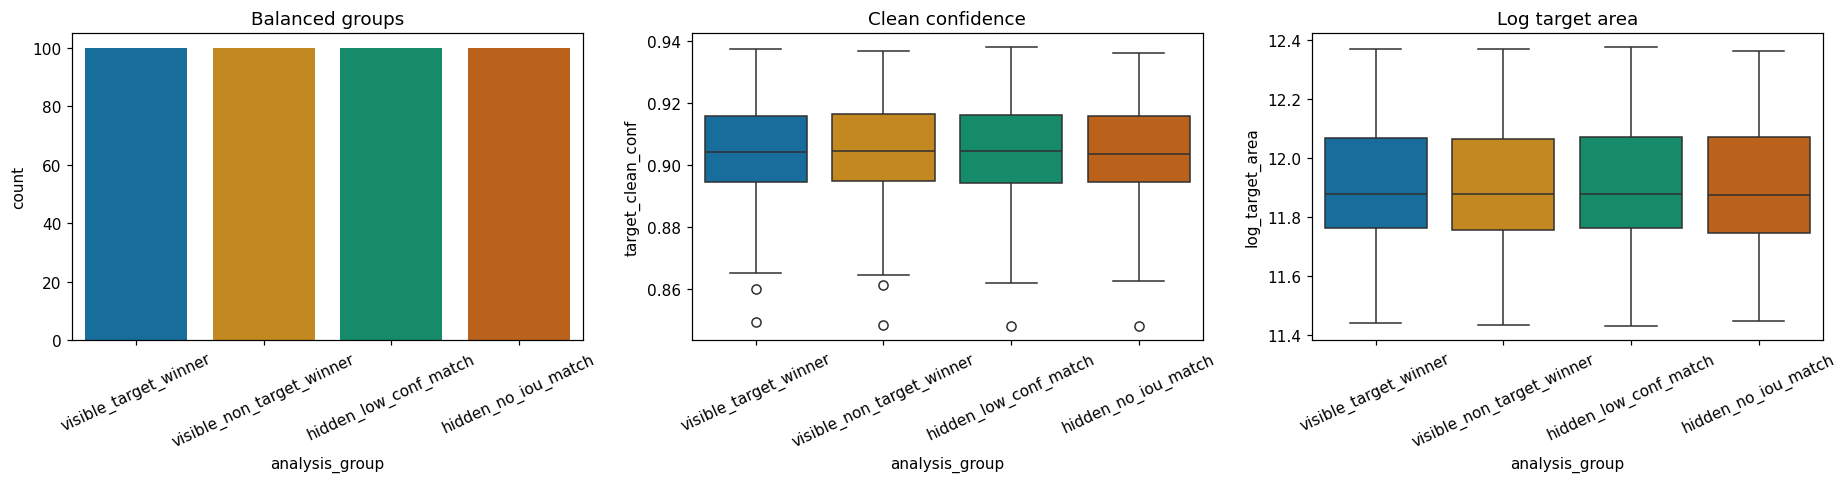

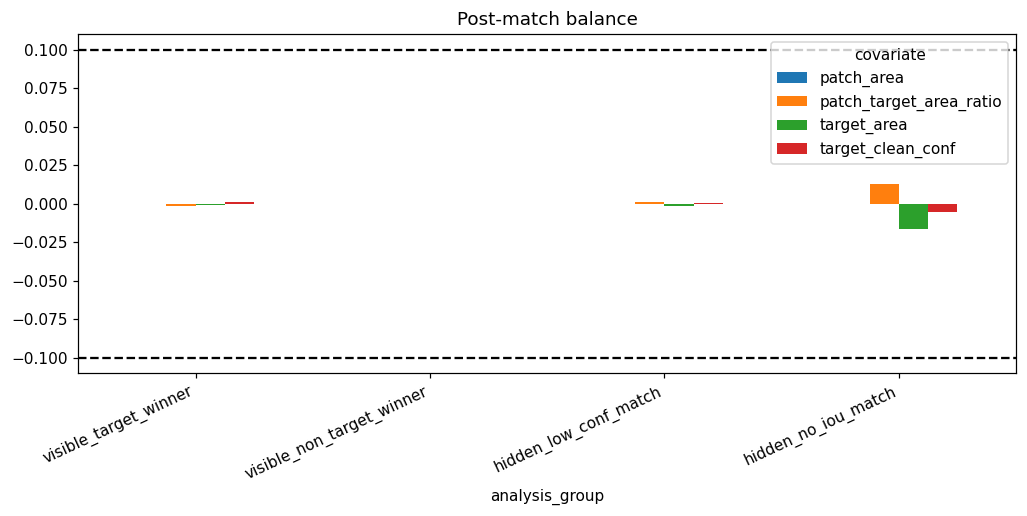

In [4]:
colors = dict(zip(GROUP_ORDER, sns.color_palette('colorblind', len(GROUP_ORDER))))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.countplot(data=manifest, x='analysis_group', order=GROUP_ORDER, hue='analysis_group', palette=colors, legend=False, ax=axes[0])
sns.boxplot(data=manifest, x='analysis_group', y='target_clean_conf', order=GROUP_ORDER, hue='analysis_group', palette=colors, legend=False, ax=axes[1])
sns.boxplot(data=manifest.assign(log_target_area=np.log(manifest.target_area)), x='analysis_group', y='log_target_area', order=GROUP_ORDER, hue='analysis_group', palette=colors, legend=False, ax=axes[2])
for ax, title in zip(axes, ['Balanced groups', 'Clean confidence', 'Log target area']): ax.set_title(title); ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()
smd = balance.pivot(index='analysis_group', columns='covariate', values='standardized_mean_difference').reindex(GROUP_ORDER)
ax = smd.plot.bar(figsize=(11,4)); ax.axhline(.1, color='black', ls='--'); ax.axhline(-.1, color='black', ls='--'); ax.set_title('Post-match balance'); plt.xticks(rotation=25, ha='right'); plt.show()

**Первая фигура.** Во всех четырёх outcome-группах ровно по `100` примеров. Распределения clean confidence практически совпадают (медиана около `0.90`), как и распределения log target area. Значит, дальнейшие различия нельзя просто списать на то, что hidden-цели изначально менее уверенные или имеют другой масштаб.

**Вторая фигура.** После matching standardized mean differences для patch area, patch/target area ratio, target area и clean confidence лежат примерно в диапазоне `−0.02…0.01`, далеко внутри принятой границы `|SMD| < 0.1`. Баланс особенно точен для первых трёх групп; небольшое остаточное смещение `hidden_no_iou_match` также мало. Это подтверждает пригодность matched quartets для сравнения механизмов, хотя баланс проверен только по перечисленным observable covariates.

## Signed clean-to-patched path

In [5]:
path_config = AttackPathConfig(
    output_dir=str(OUTPUT_ROOT), max_output_gb=8.0, max_examples=None,
    n_steps=N_STEPS, alpha_batch_size=4, target_kinds=('tracked_clean',),
    top_contributions=1000, visual_map_examples=48, selection_seed=SEED,
    selection_manifest=str(selection.manifest_path), progress=True,
)
if RUN_ATTACK_PATH:
    path_result = run_attack_path_decomposition(exp, TRACE_DB, path_config, force=FORCE_ATTACK_PATH)
    print('DB:', path_result.db_path); print('digest:', path_result.digest_path)
else:
    raise RuntimeError('Set RUN_ATTACK_PATH=True, or assign an existing path_result')

attack-path decomposition:   0%|          | 0/400 [00:00<?, ?img/s]

DB: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/attack_path_0060cc9878ecdb6e/attack_path.sqlite
digest: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/attack_path_0060cc9878ecdb6e/analysis_digest.md


,target_kind,analysis_group,n,exact_score_delta_mean,exact_score_delta_median,first_order_sum_mean,first_order_sum_median,first_order_residual_mean,first_order_residual_median,total_abs_contribution_mean,total_abs_contribution_median,positive_contribution_mean,positive_contribution_median,negative_contribution_mean,negative_contribution_median,top0p1_abs_fraction_mean,top0p1_abs_fraction_median,top1_abs_fraction_mean,top1_abs_fraction_median,top2_abs_fraction_mean,top2_abs_fraction_median
0,tracked_clean,hidden_low_conf_match,100,-6.424080,-5.660399,-1.602464,-1.599619,-4.821616,-3.994819,24.002699,21.615972,8.788741,7.462767,-15.213958,-13.539443,0.810175,0.806542,1.0,1.0,1.0,1.0
1,tracked_clean,hidden_no_iou_match,100,-7.666877,-8.181321,-1.590696,-1.585600,-6.076181,-6.299200,28.909217,28.962072,10.619218,10.328022,-18.290000,-19.173026,0.809476,0.803747,1.0,1.0,1.0,1.0
2,tracked_clean,visible_non_target_winner,100,-3.367701,-2.579495,-1.089463,-1.122037,-2.278238,-1.578568,13.049203,10.977092,4.840226,4.112320,-8.208976,-6.791743,0.805926,0.802435,1.0,1.0,1.0,1.0
3,tracked_clean,visible_target_winner,100,-3.557203,-2.438089,-0.929334,-0.886620,-2.627870,-1.402848,14.602355,10.757699,5.520843,4.119904,-9.081513,-6.318184,0.799474,0.791733,1.0,1.0,1.0,1.0


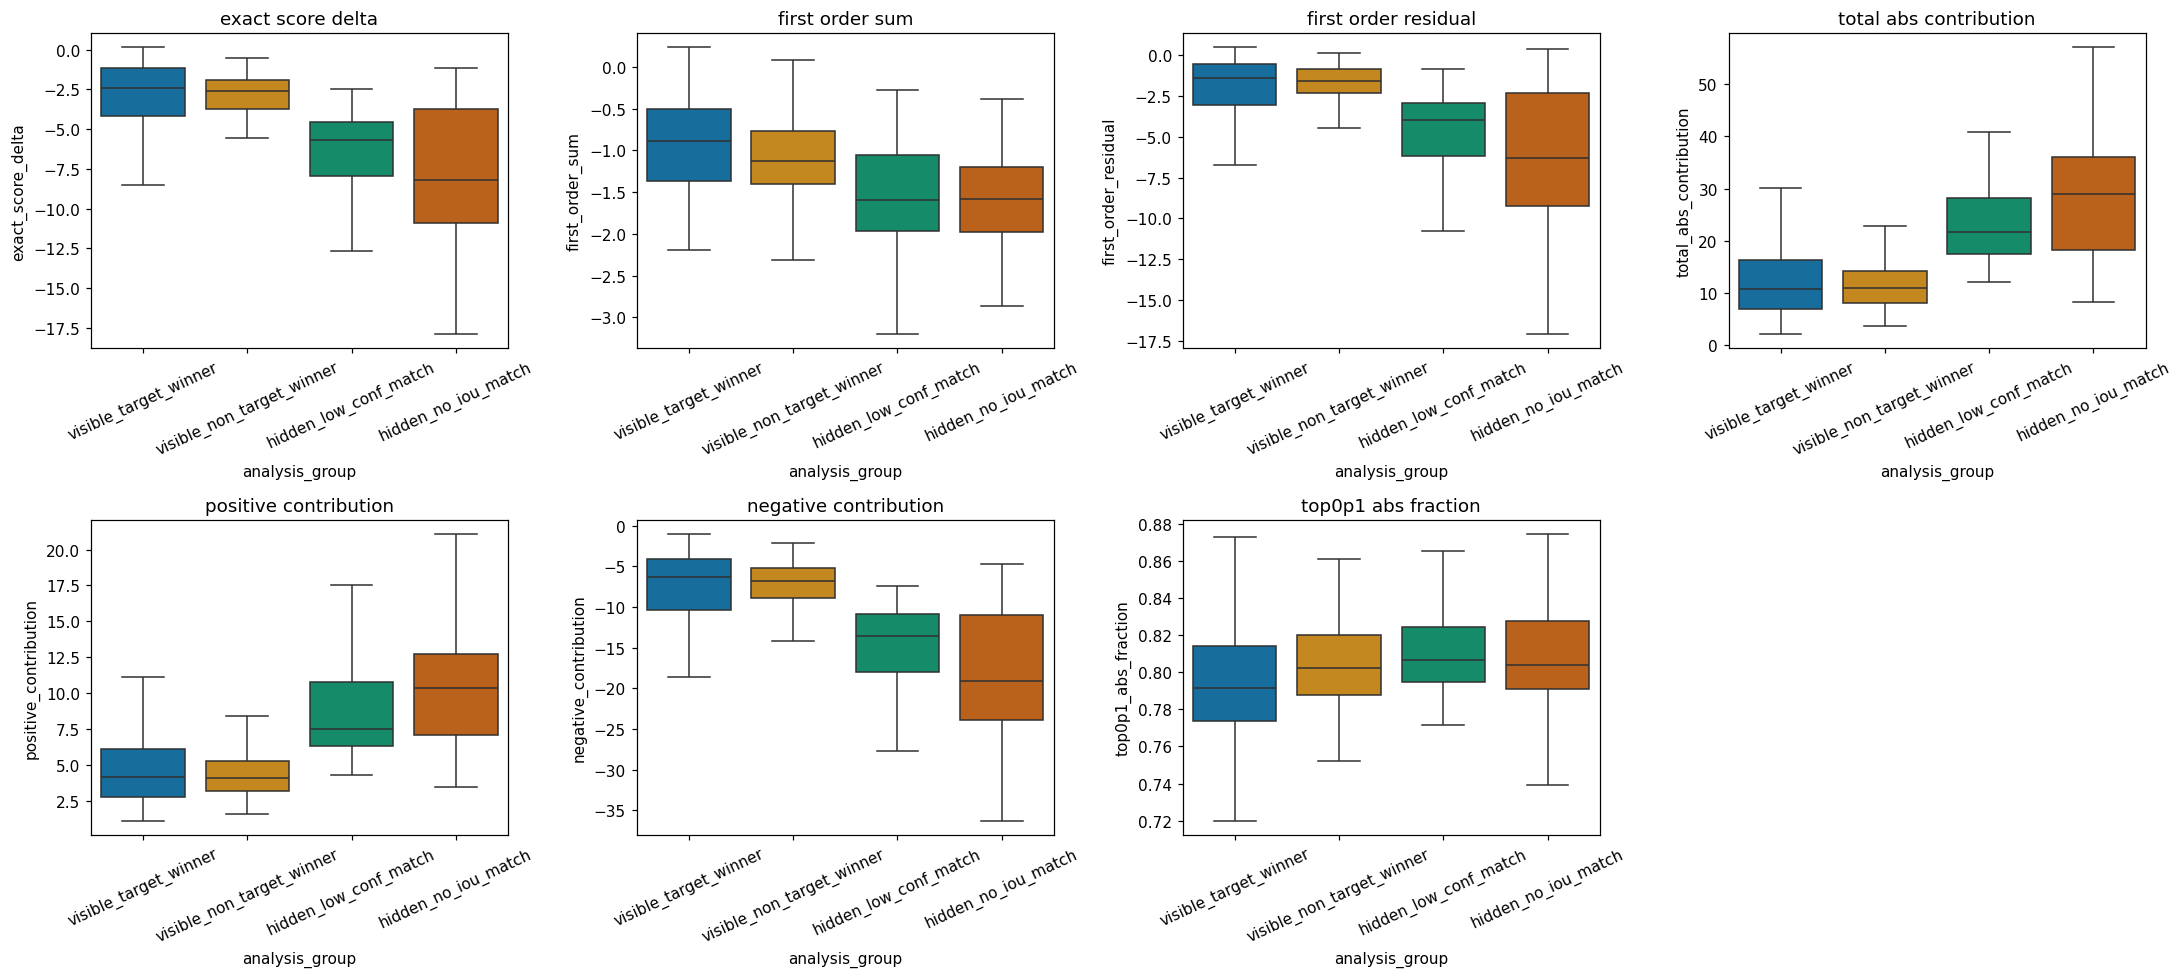

In [6]:
artifacts = summarize_balanced_attack_path(path_result.db_path, path_result.run_dir / 'balanced_target_analysis')
tables = load_attack_path_tables(path_result)
examples = tables['examples'].rename(columns={'mechanism_mode': 'analysis_group'}).merge(
    manifest[['example_id', 'match_set']], on='example_id', how='left', validate='one_to_one',
)
group_summary = pd.read_csv(artifacts['group_summary'])
display(group_summary)
metrics = ['exact_score_delta','first_order_sum','first_order_residual','total_abs_contribution','positive_contribution','negative_contribution','top0p1_abs_fraction']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, metric in zip(axes.flat, metrics):
    sns.boxplot(data=examples, x='analysis_group', y=metric, order=GROUP_ORDER, hue='analysis_group', palette=colors, legend=False, showfliers=False, ax=ax)
    ax.set_title(metric.replace('_',' ')); ax.tick_params(axis='x', rotation=25)
axes.flat[-1].axis('off'); plt.tight_layout(); plt.show()

**Что видно на графике.** У hidden-групп clean→patched падение target score существенно сильнее: в среднем `−6.42` для low-confidence и `−7.67` для no-IoU против `−3.37…−3.56` у видимых групп. Одновременно растёт полный signed activity: total absolute contribution равен примерно `24.0/28.9` против `13.0/14.6`, а отрицательная сумма — `−15.2/−18.3` против `−8.2/−9.1`. Это поддерживает гипотезу более сильного воздействия патча на target-path при успешной атаке.

Однако first-order sum (посчитанный взятием градиента по нейрону на чистой картинке и затем домножением этого градиента на дельту) различается намного слабее (`≈−1.6` у hidden против `−0.93…−1.09` у visible), а основная разница сидит в nonlinear residual (`−4.82/−6.08` против `−2.28/−2.63`). Поэтому механизм нельзя свести к локальной линейной чувствительности около clean-входа. Доля absolute contribution в top `0.1%` почти одинакова во всех группах (`≈0.80–0.81`), то есть успешные атаки отличаются амплитудой и нелинейностью, но не очевидной большей концентрацией support.

## Primary paired comparison

Поскольку выборка состоит из matched quartets, primary test сравнивает `hidden_low_conf_match` и `hidden_no_iou_match` попарно по `match_set`.

In [ ]:
wide = examples.pivot(index='match_set', columns='analysis_group', values=metrics)
rows = []
for metric in metrics:
    delta = wide[metric]['hidden_no_iou_match'] - wide[metric]['hidden_low_conf_match']
    rows.append({'metric': metric, 'paired mean difference': delta.mean(), 'paired median difference': delta.median(), 'wilcoxon p': wilcoxon(delta).pvalue})
paired = pd.DataFrame(rows)
order = np.argsort(paired['wilcoxon p'].to_numpy()); p = paired['wilcoxon p'].to_numpy()[order]
adjusted = np.minimum(1, np.maximum.accumulate(p * (len(p)-np.arange(len(p)))))
paired['holm p'] = np.nan; paired.loc[paired.index[order], 'holm p'] = adjusted
display(paired.sort_values('holm p'))
print('compact outputs:', artifacts)

,metric,paired mean difference,paired median difference,wilcoxon p,holm p
4,positive_contribution,1.830477,1.808319,0.001453,0.010172
3,total_abs_contribution,4.906518,3.728627,0.002685,0.016111
5,negative_contribution,-3.076041,-2.472960,0.004414,0.022071
2,first_order_residual,-1.254565,-0.767285,0.011841,0.047363
0,exact_score_delta,-1.242797,-0.618444,0.019206,0.057619
1,first_order_sum,0.011768,0.009921,0.759596,1.000000
6,top0p1_abs_fraction,-0.000699,-0.001200,0.720653,1.000000


compact outputs: {'group_summary': PosixPath('/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/attack_path_0060cc9878ecdb6e/balanced_target_analysis/balanced_attack_path_group_summary.csv'), 'pairwise': PosixPath('/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/attack_path_0060cc9878ecdb6e/balanced_target_analysis/balanced_attack_path_pairwise.csv'), 'digest': PosixPath('/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/attack_path_0060cc9878ecdb6e/balanced_target_analysis/analysis_digest.md')}


: 